<a href="https://www.kaggle.com/code/malavpatel17/digit-recognizer-pca?scriptVersionId=309596827" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import matplotlib.pyplot as plt

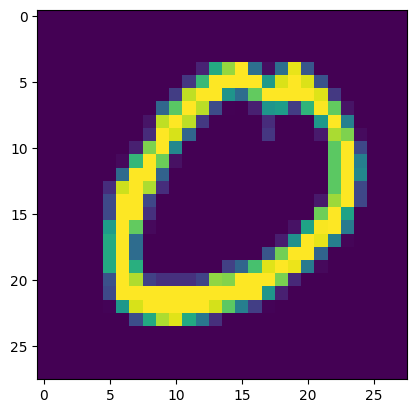

In [5]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))

In [6]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state =42)

In [8]:
from sklearn.neighbors import KNeighborsClassifier 

In [9]:
knn = KNeighborsClassifier()

In [10]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [11]:
y_pred = knn.predict(x_test)


In [12]:
y_pred

array([8, 1, 9, ..., 3, 0, 9])

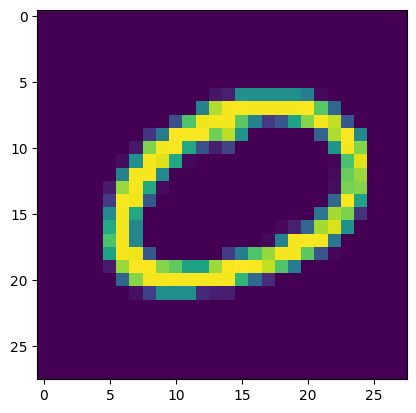

In [13]:
plt.imshow(x_test.iloc[-2].values.reshape(28,28))

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)*100

96.48809523809524

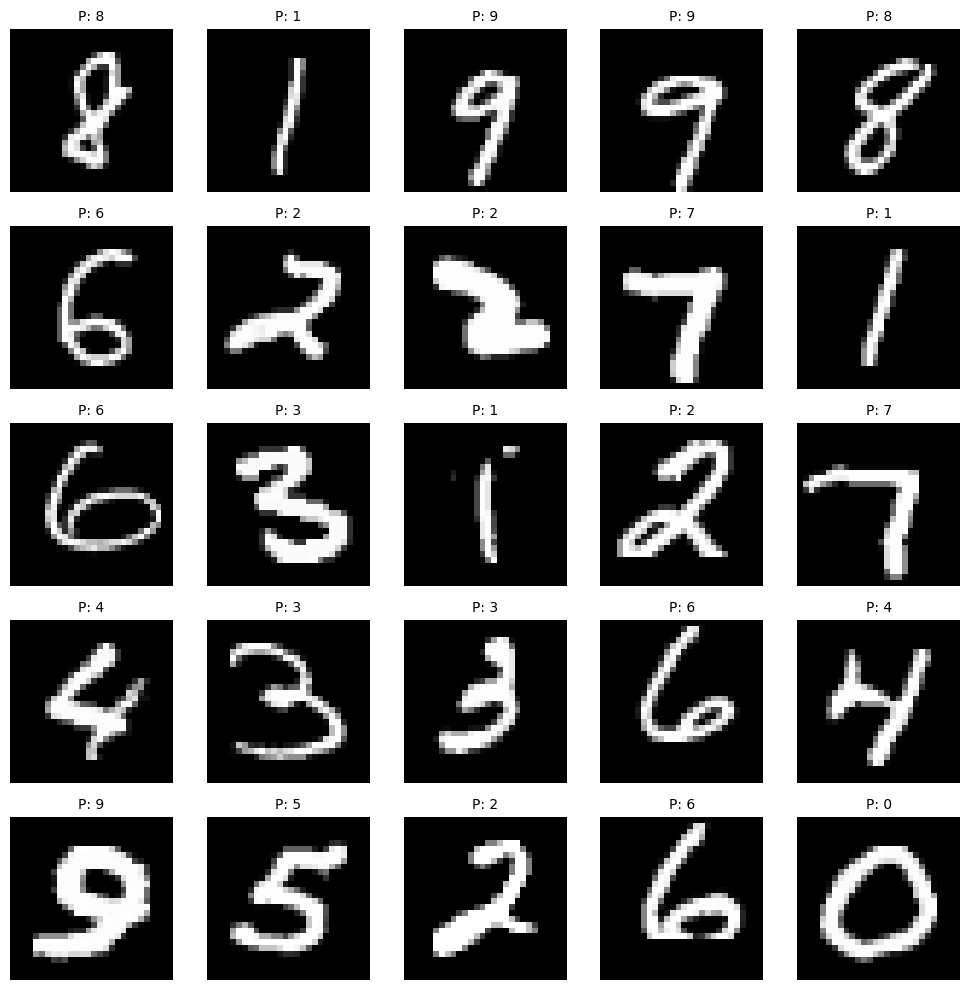

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 5, figsize=(10, 10))  # 5x5 grid

for i, ax in enumerate(axes.flat):
    ax.imshow(x_test.iloc[i].values.reshape(28, 28), cmap='gray')
    ax.set_title(f"P: {y_pred[i]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("output")
plt.show()

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)  # reduce 784 → 50
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [17]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn.fit(x_train_pca, y_train)
y_pred = knn.predict(x_test_pca)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9746428571428571
[[811   0   0   0   0   1   2   0   0   2]
 [  0 907   0   0   0   0   2   0   0   0]
 [  3   6 821   2   0   0   1   9   1   3]
 [  0   2   5 896   0  15   1   3  10   5]
 [  1   1   0   0 811   0   4   3   0  19]
 [  0   1   0   4   0 681   6   0   5   5]
 [  3   0   0   0   0   2 778   0   2   0]
 [  0  12   4   2   1   0   0 865   0   9]
 [  0   2   5   4   2  10   2   1 804   5]
 [  1   1   1   5   4   1   0  10   2 813]]


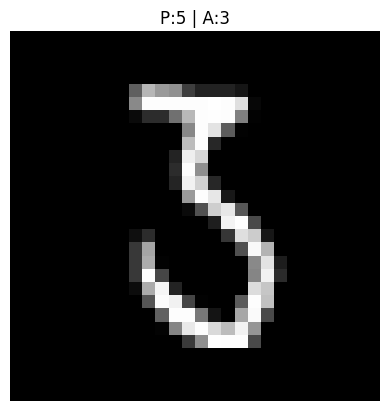

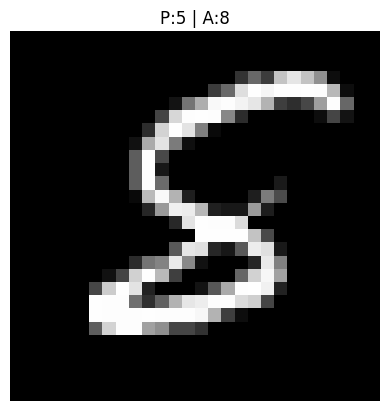

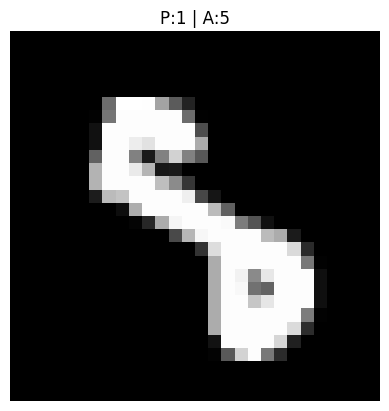

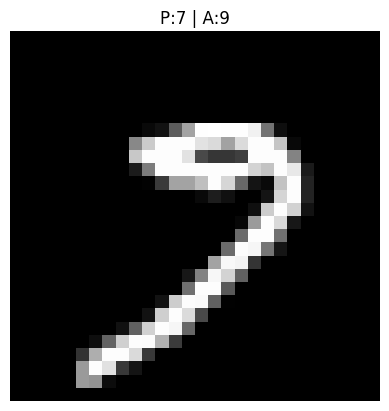

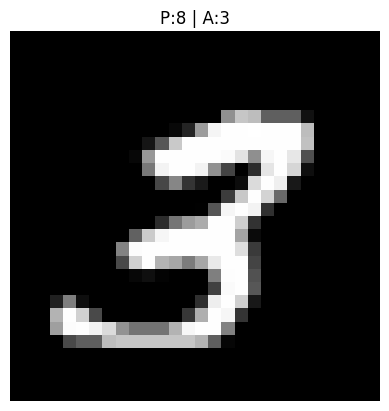

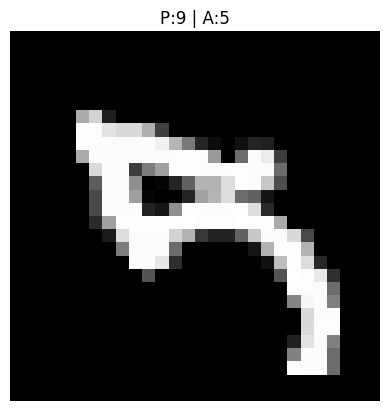

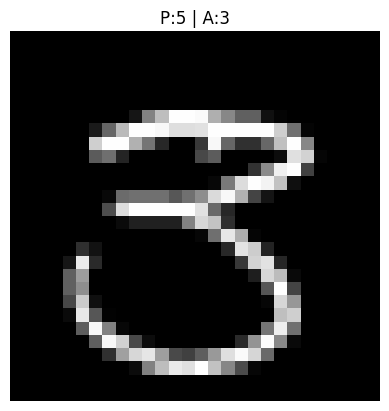

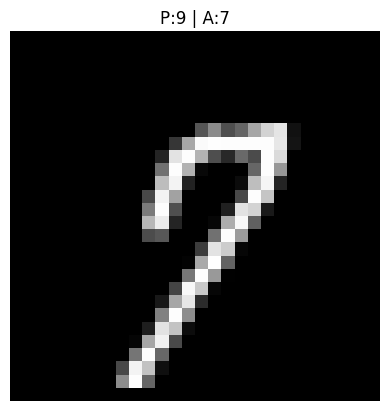

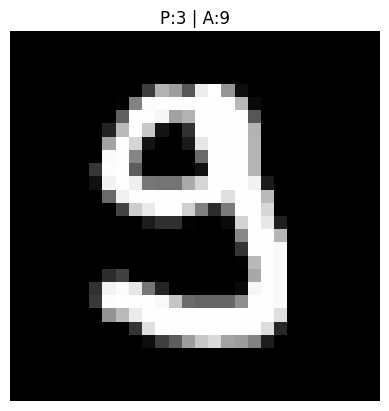

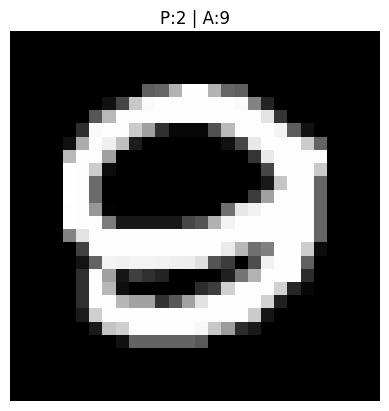

In [19]:
wrong = np.where(y_pred != y_test)[0]

for i in wrong[:10]:
    plt.imshow(x_test.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title(f"P:{y_pred[i]} | A:{y_test.iloc[i]}")
    plt.axis('off')
    plt.show()

In [20]:
test_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

test_df = test_df / 255.0
test_pca = pca.transform(test_df)

final_pred = knn.predict(test_pca)

submission = pd.DataFrame({
    "ImageId": range(1, len(final_pred)+1),
    "Label": final_pred
})

submission.to_csv("submission.csv", index=False)